**STUDENT: Joel S. Mollel**

**NUMBER: C00313599**

**ALGORITHM: Decision Trees**

Provided with two blocks of code, one is a random number generator and classifier and another is a Decision Tree Classifier which classified the numbers generated by the earlier code.

**CHANGE-LOG**

The following is what I did to the code given. Number 4 is the deepest of all. It introduces a new dataset and the changes in the given code to accommodate this new dataset. It also tests the impact of different factors related to decision tree on the classification work. The Decision Tree Drug Prescription System is also in number 4.

| SN | Change Made                                                   | Reason                                                                                                                                  | Time Taken                   |
|----|---------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------|------------------------------|
| 1  | Run the given code on the notebook                             | Ran smoothly without issues                                                                                                              | <10 minutes                  |
| 2  | Adjusted the number of clusters to see their impact on classification | To analyze how different clusters affect classification                                                                                   | <15 minutes                  |
| 3  | Tested the impact of tree depth (pruning) on model accuracy   | Struggled to understand how to use tree depth in the code                                                                                 | Approximately 2 hours         |
| 4  | Found and integrated a new dataset (`drug200.csv`)            | To replace synthetic data with a real-world dataset for classification                                                                  | 30 minutes            |
| 4.1| Dataset Handling: Loaded dataset using `pd.read_csv()`        | To import a real-world dataset                                                                                                          | <10 minutes                  |
| 4.2| Feature Mapping: Converted categorical features to numerical | For compatibility with machine learning algorithms                                                                                       | 15 minutes |
| 4.3| Feature and Target Selection: Declared features and target variable | To prepare data for training the model                                                                                                  | Approximately 1 hour          |
| 4.4| Encoding of Target Variable using `LabelEncoder()`            | To convert the target variable into numerical form for machine learning algorithms                                                      | Same as feature mapping      |
| 5  | Performed Train-Test Split with 70-30 ratio                   | To evaluate the model’s performance by splitting data into training and test sets                                                        | Approximately 40 minutes      |
| 6  | Applied Feature Scaling with `StandardScaler()`               | To ensure all features are on the same scale and improve model performance                                                                | More than 2 hours             |
| 7  | Trained the Decision Tree Classifier model                    | To train the model using scaled data                                                                                                     | <10 minutes                  |
| 8  | Visualized the decision tree using `plot_tree()`              | To visualize the trained decision tree                                                                                                   | More than 4 hours             |
| 9  | Simulated user input for tree depth (pruning)                 | To observe the effect of tree depth on model accuracy                                                                                    | <30 minutes                  |
| 10 | Simulated a Decision Tree Drug Prediction System             | To allow users to input patient features and classify them into drug types                                                               | <30 minutes                  |


*1: RUNNING THE CODE PROVIDED*

(a) The code generates 300 synthesized number samples and classifies them into 4 clusters with different colors.
The code below did run well after the installation of the libraries I have listed in the requirements.txt file I have associated with this project.

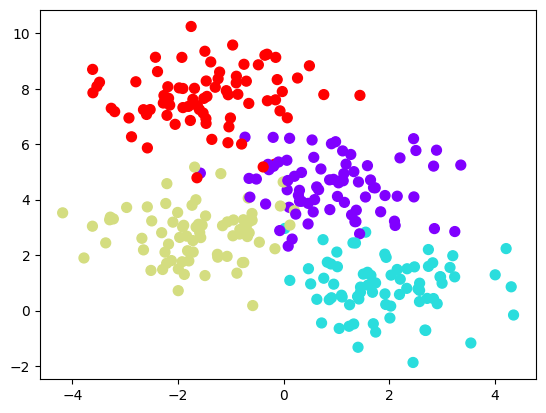

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow')
plt.show() # This will display the plot

*2: IMPACTS OF CLUSTER SIZE AND TREE DEPTH ON THE MODEL*

(a) Testing the impact of the number of clusters on the classification of generated numbers

I will change the number of clusters while maintaining the standard deviation to see the number that will result in a better classification.

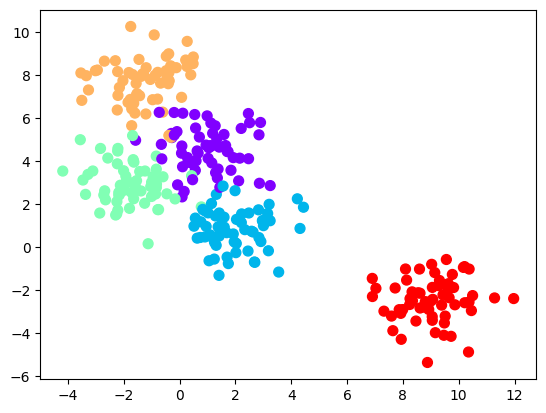

In [3]:
X, y = make_blobs(n_samples=300, centers=5, ## JM: 5 clusters
random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

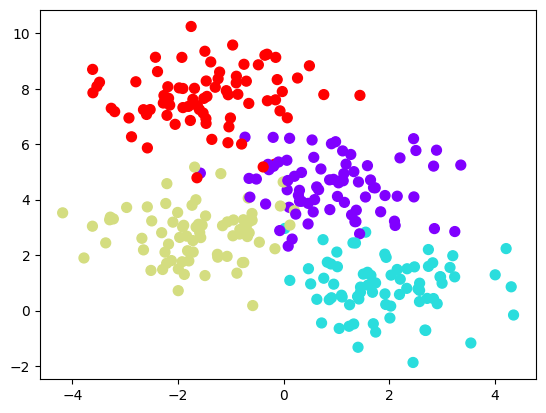

In [4]:
X, y = make_blobs(n_samples=300, centers=4, ## JM: 4 Clusters
random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

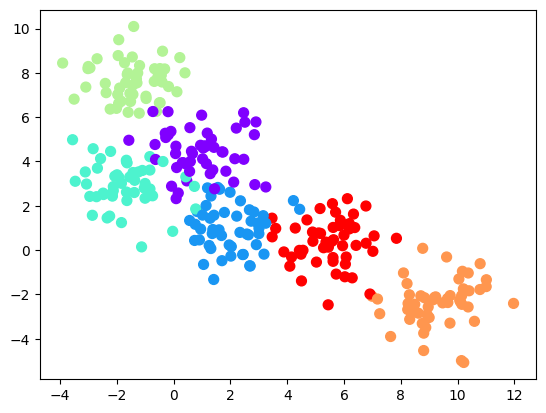

In [7]:
X, y = make_blobs(n_samples=300, centers=6, ##JM: 6 Clusters
random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

**Conclusion on the impact of the number of clusters:** The number of clusters determines the accuracy of the decision tree classifier. In this case, the model classifies the dataset into 5 clusters better than it did in different cluster sizes.

    3. RUNNING THE SECOND CODE GIVEN - CLASSIFYING THE GENERATED DATASET USING DECISION TREE

(a) After the installation of libraries, the program did run

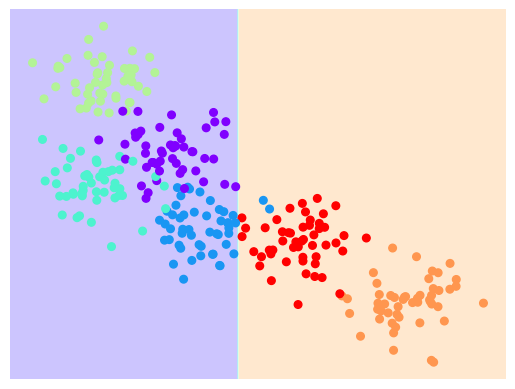

In [9]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)
import numpy as np
import matplotlib.pyplot as plt
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca() # JM: Use the current axis or create a new one
    # JM: Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap, zorder=3)
    ax.axis('tight') # JM: Set axis limits tight to the data
    ax.axis('off') # JM: Turn off axis
    xlim = ax.get_xlim() # JM: Get the x-axis limits
    ylim = ax.get_ylim() # JM: Get the y-axis limits
    # JM: Fit the model to the data
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200), # JM: Create a meshgrid for decision boundaries
    np.linspace(*ylim, num=200)) # JM: Create a meshgrid for decision boundaries
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) # JM: Predict class labels ove
    # JM: Create a color plot with the decision boundaries
    n_classes = len(np.unique(y)) # JM: Get the number of classes
    contours = ax.contourf(xx, yy, Z, alpha=0.3, # JM: Plot decision boundaries
    levels=np.arange(n_classes + 1) - 0.5,
    cmap=cmap, zorder=1) # JM: Set contour fill properties
    ax.set(xlim=xlim, ylim=ylim) # JM: Set axis limits
# JM: Visualize the classifier with a decision tree model of max depth 1
visualize_classifier(DecisionTreeClassifier(max_depth=1), X, y)

(b) I want to implement pruning by changing the depth, which is the hyper-parameter in the model, to see the impact.

I will use max_depth=3, max_depth=5, and max_depth=7. This will help us locate the more appropriate depth for classification. It will also show us underfitting and overfitting concepts.
When we decrease depth, it is technically tree pruning, a concept we also covered in the class.

**Max depth = 1, see results below**

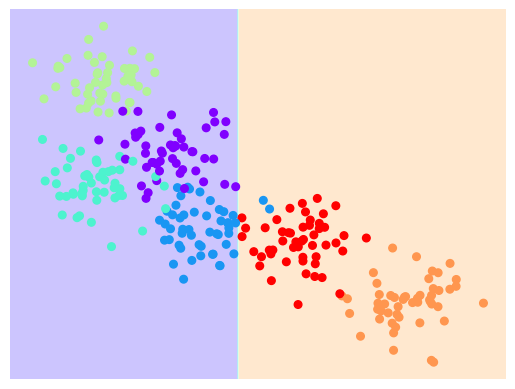

In [10]:
visualize_classifier(DecisionTreeClassifier(max_depth=1), X, y)

**Max depth = 3 classified the data as follows**

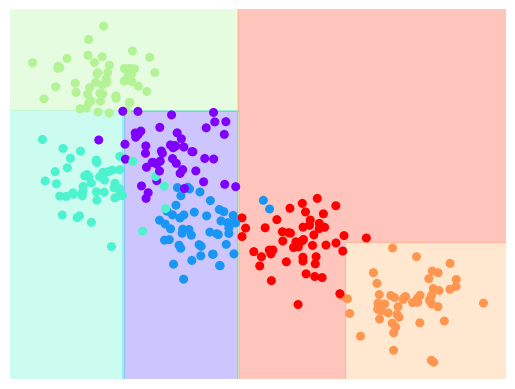

In [12]:
visualize_classifier(DecisionTreeClassifier(max_depth=3), X, y)

**Max depth = 5 gave the result below**

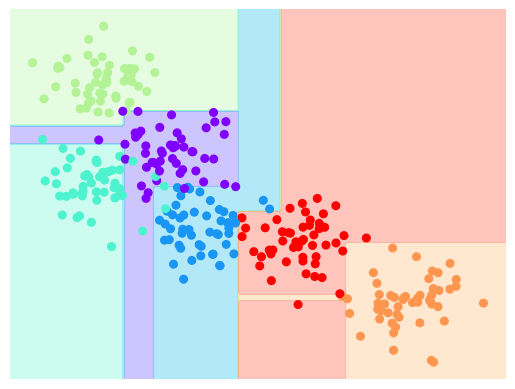

In [14]:
visualize_classifier(DecisionTreeClassifier(max_depth=5), X, y)

**Max depth = 7 gave the following results**

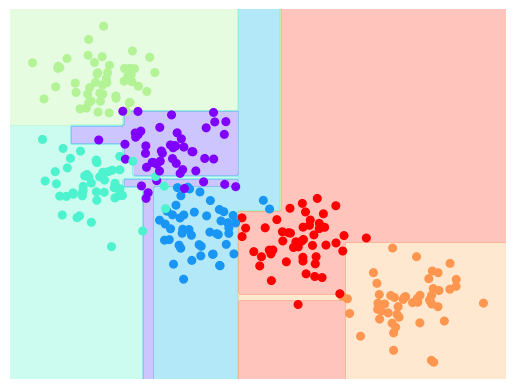

In [15]:
visualize_classifier(DecisionTreeClassifier(max_depth=7), X, y)

**Conclusion on max_depth changes:** When the value of max_depth was 1, the model was underfitting, missing important details. When the value was changed to 3, there was an improvement, and when max_depth was 5, the model did the best classification work. When max_depth was set to 7, there was overfitting, as you can observe from the above plot.

**4. NEW DATASET**

I will use the drug200.csv dataset which prescribes drugs to patients based on their age, sex, BP, cholesterol, and Sodium to potassium ratio.

The goal is to:

    i) Visualize the dataset on the decision tree

    ii) Show important features that determine the value of target labels

    iii) Measure the impact of tree depth on the accuracy and depth of the tree

    iv) The Decision Tree Medical Prescription System modeling

**i) Visualizing the dataset on the Decision Tree**


**STEPS**

    

**Step 1: Importing libraries and loading data**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('drug200.csv')

**Step 2: Getting a general idea of the dataset, viewing the head**

In [19]:
print(df.head())

   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY


**Step 3: Encoding categorical variables to work with the model**

In [20]:
df['Sex'] = df['Sex'].map({'F': 0, 'M': 1}) # 'F' -> 0, 'M' -> 1
df['BP'] = df['BP'].map({'LOW': 0, 'NORMAL': 1, 'HIGH': 2})
df['Cholesterol'] = df['Cholesterol'].map({'NORMAL': 0, 'HIGH': 1})

**Step 4: Extracting features and target variable**

In [21]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values ##I will use all features
y = df['Drug'].values ##This is my target variable

**Step 5: Encoding the target variable to work with the model**

In [22]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

**Step 6: Splitting dataset into training and testing datasets (70% for training, 30% for testing)**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

**Step 7: Standardise features for better performance**

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Step 8: Initializing and training decision tree classifier**

In [28]:
model = DecisionTreeClassifier(random_state=42)
# I am using all features
model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

**Step 9: Visualize the structure of Decision Tree**

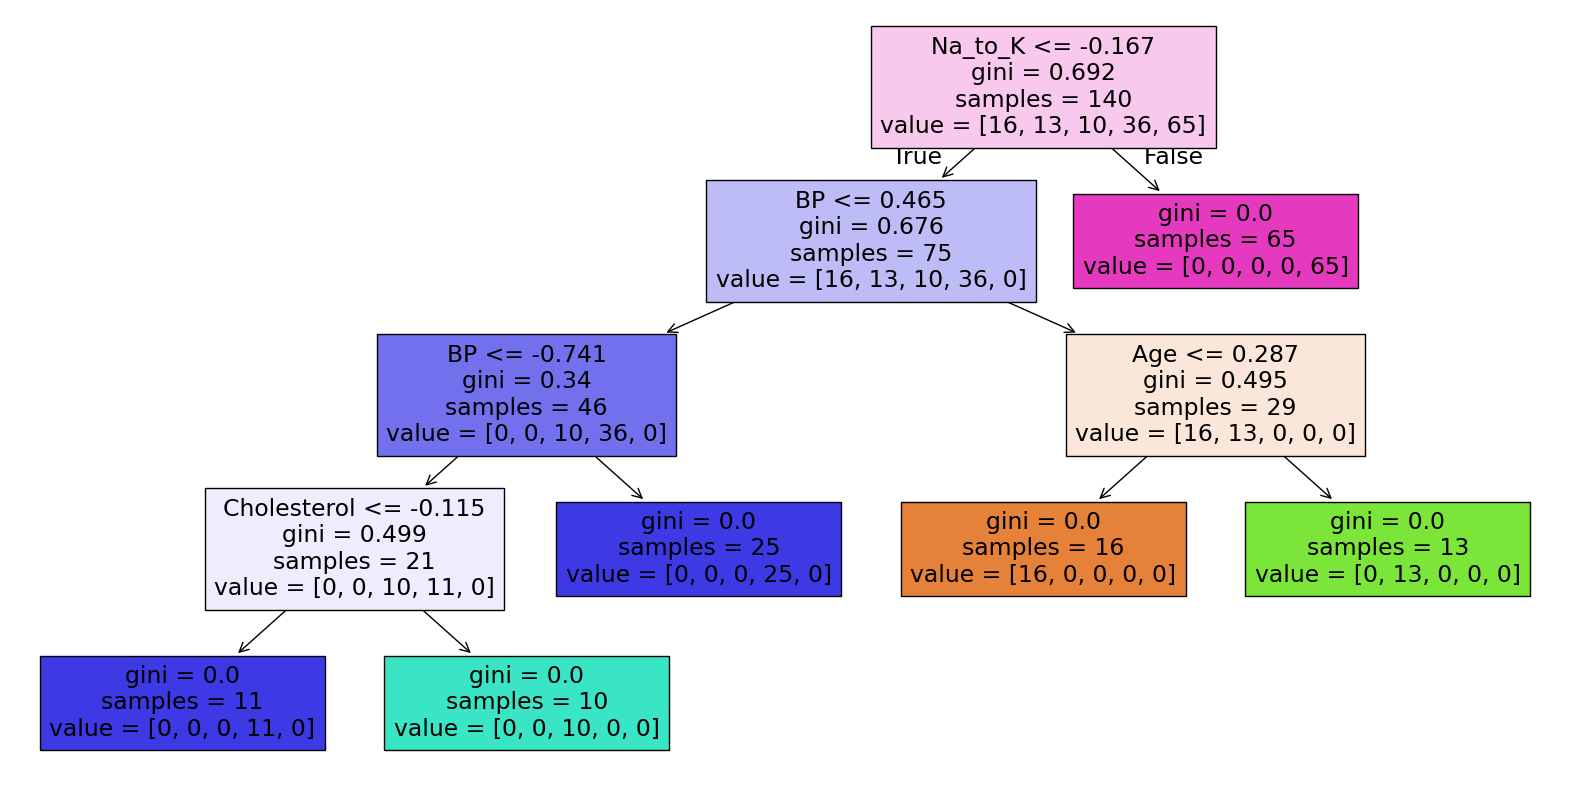

In [31]:
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'])
plt.show()

**ii)Showing the important features that determines the value of target labels**

In the decision Tree classification, some features have more influence on the classification than others. In this classification work, the importance of each feature is mentioned below where Na_to_K is the leading with o.4761 and Sex had no influence(0.0000)

In [35]:
print("\nFeature Importances:")
for feature, importance in zip(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], model.feature_importances_):
    print(f"{feature}: {importance:.4f}")


Feature Importances:
Age: 0.1482
Sex: 0.0000
BP: 0.2675
Cholesterol: 0.1082
Na_to_K: 0.4761


iii) **Prunning the tree using max_depth and its impact on the Accuracy and length of the tree**
    
The system prompt the user to enter the depth of the tree and see its impact on the size of the tree and the classification accuracy.
   

 **STEPS**

**Step 1: Importing libraries and the dataset**

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv('drug200.csv')

**Step 2: Declaration of features and target variables**

In [37]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
y = df['Drug'].values

**Step 3: Encoding the categorical target Labels(Drug), models work with numbers**

In [38]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

**4: Encoding Categorical features, that is Sex,Age,BP,Cholestrol, and Na-to-K**

In [39]:
X[:, 1] = LabelEncoder().fit_transform(X[:, 1])
X[:, 2] = LabelEncoder().fit_transform(X[:, 2])
X[:, 3] = LabelEncoder().fit_transform(X[:, 3])

**Step 4: Splitting the dataset into Trainingset(80%) and testset(20%). This is due to my dataset being small**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

**Step 5: Features Standardization**

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Step 6: Prompt the user to enter the max_depth value.** This provides flexibility than hardcoding. Train the model.

Print the decision tree based on the max_depth value entered and also see the accuracy obtained by the same depth

Enter the max_depth value for the Decision Tree:  3


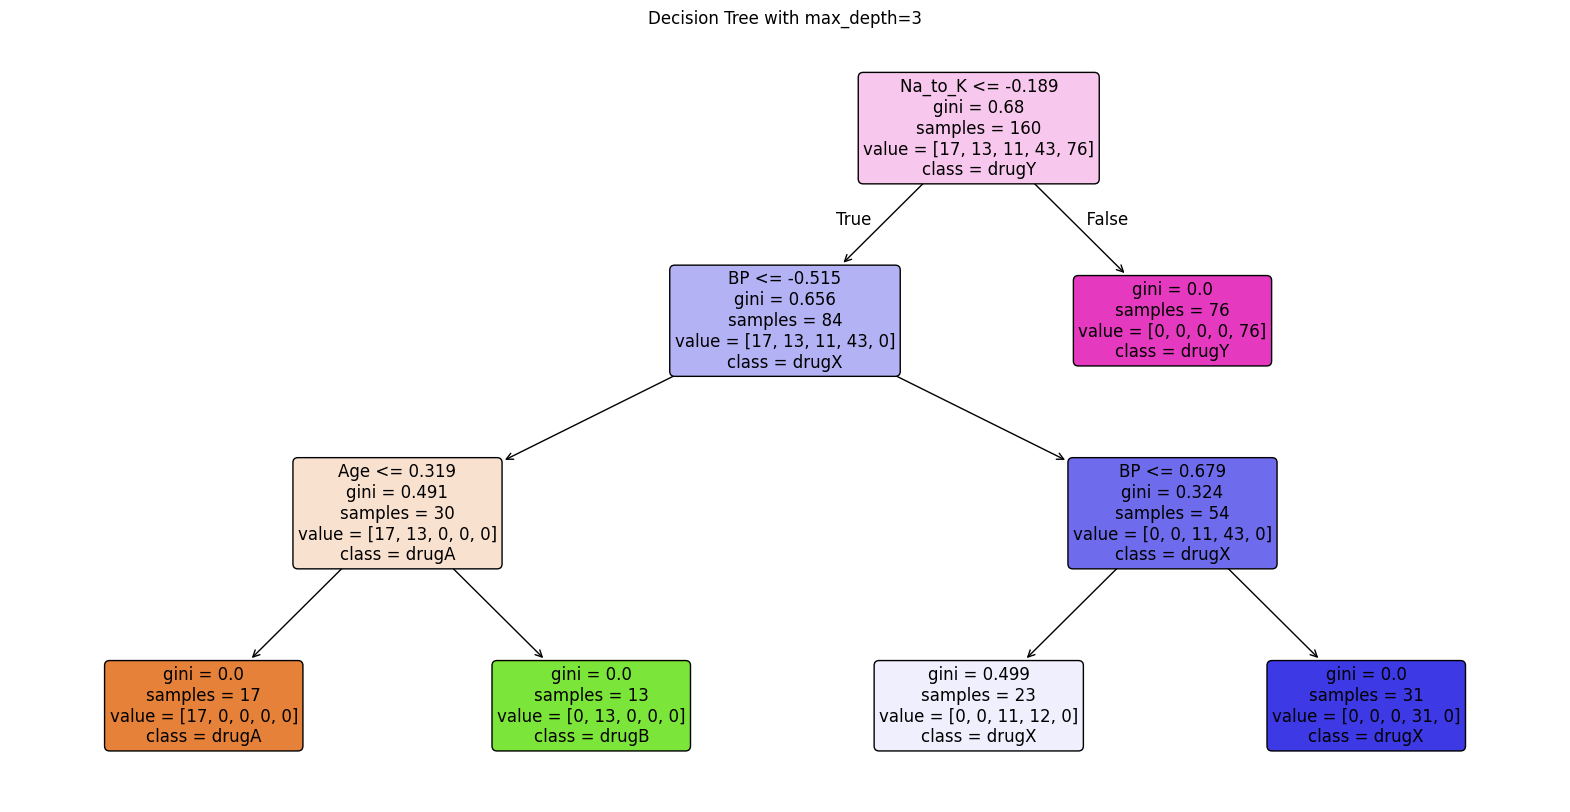

Accuracy of Decision Tree with max_depth=3: 0.8750


In [43]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

max_depth = int(input("Enter the max_depth value for the Decision Tree: "))
model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
model.fit(X_train_scaled, y_train)

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], 
          class_names=encoder.classes_, rounded=True, fontsize=12)
plt.title(f"Decision Tree with max_depth={max_depth}")
plt.show()

accuracy = model.score(X_test_scaled, y_test)
print(f"Accuracy of Decision Tree with max_depth={max_depth}: {accuracy:.4f}")


**iv) Decision Tree Medical Prescription System**

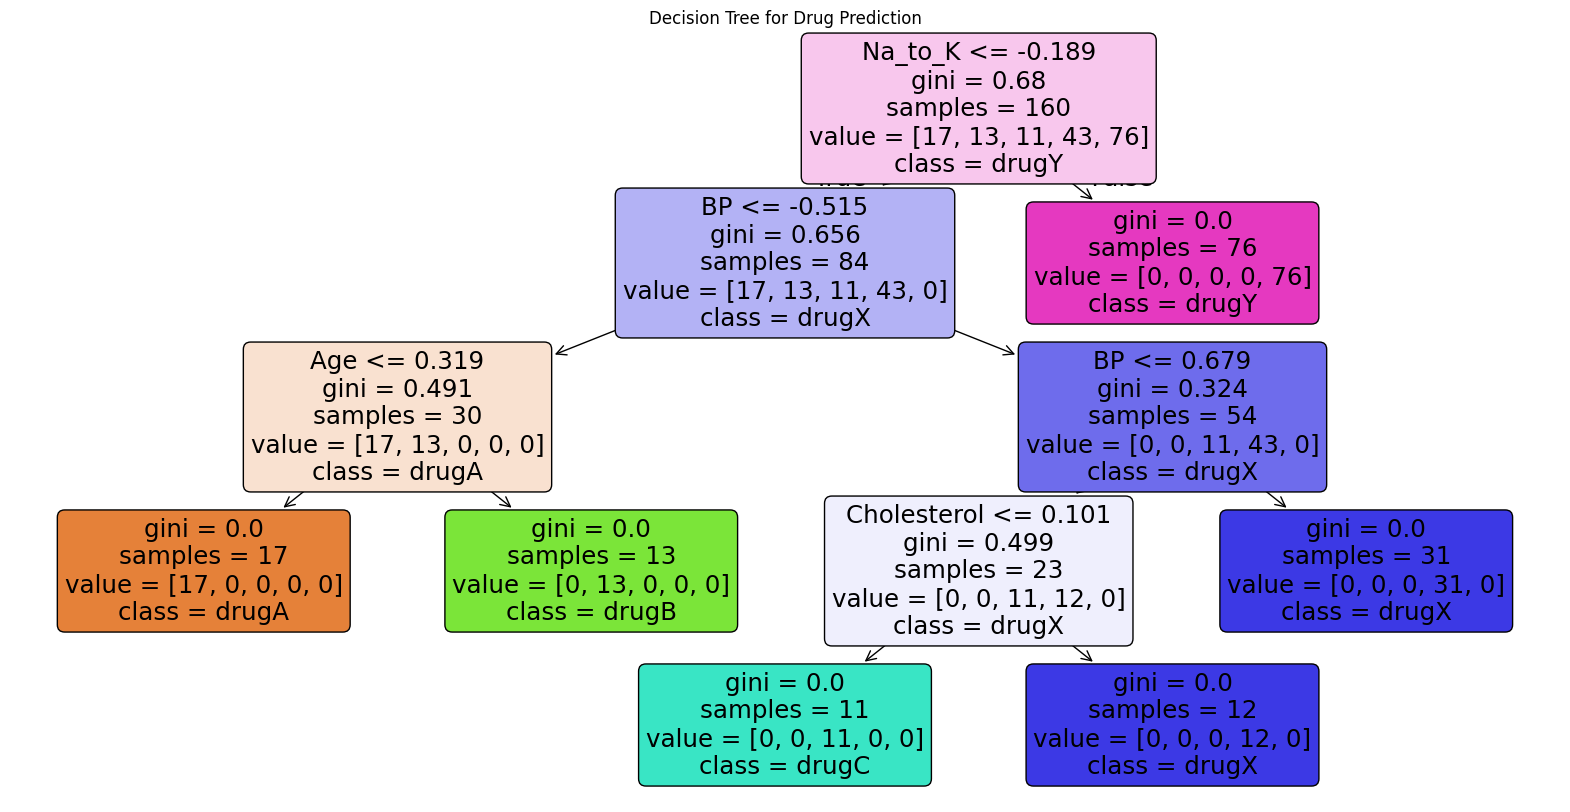

**************************************************
Welcome to the Decision Tree Drug Prescription System.
See the structure of our Decision Tree Classification system above.
Please enter the patient's details below and wait for the decision tree to provide the appropriate prescription.


Enter the patient's Age:  3
Enter the patient's Sex (M/F):  m
Enter the patient's BP (LOW/NORMAL/HIGH):  low
Enter the patient's Cholesterol level (NORMAL/HIGH):  high
Enter the patient's Na_to_K value:  23


The predicted drug for the patient is: drugY
Accuracy of the Decision Tree: 100.00%


In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('drug200.csv')

# Encode categorical variables
encoder = LabelEncoder()
data['Sex'] = encoder.fit_transform(data['Sex'])  # M: 1, F: 0
data['BP'] = encoder.fit_transform(data['BP'])  # HIGH: 0, LOW: 1, NORMAL: 2
data['Cholesterol'] = encoder.fit_transform(data['Cholesterol'])  # HIGH: 0, NORMAL: 1
data['Drug'] = encoder.fit_transform(data['Drug'])  # drugA: 0, drugB: 1, drugC: 2, drugX: 3, drugY: 4

# Define features and target
X = data[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]
y = data['Drug']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the numerical columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the decision tree classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    model, filled=True,
    feature_names=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'],
    class_names=['drugA', 'drugB', 'drugC', 'drugX', 'drugY'],
    rounded=True
)
plt.title("Decision Tree for Drug Prediction")
plt.show()

# Welcome message
print("*" * 50)
print("Welcome to the Decision Tree Drug Prescription System.")
print("See the structure of our Decision Tree Classification system above.")
print("Please enter the patient's details below and wait for the decision tree to provide the appropriate prescription.")

# User input for prediction
def predict_drug():
    age = int(input("Enter the patient's Age: "))
    sex = input("Enter the patient's Sex (M/F): ").upper()
    bp = input("Enter the patient's BP (LOW/NORMAL/HIGH): ").upper()
    cholesterol = input("Enter the patient's Cholesterol level (NORMAL/HIGH): ").upper()
    na_to_k = float(input("Enter the patient's Na_to_K value: "))

    # Encoding user input
    sex = 1 if sex == 'M' else 0
    bp = {'HIGH': 0, 'LOW': 1, 'NORMAL': 2}[bp]
    cholesterol = {'HIGH': 0, 'NORMAL': 1}[cholesterol]

    # Prepare input data as a DataFrame with feature names
    input_data = pd.DataFrame([[age, sex, bp, cholesterol, na_to_k]], 
                              columns=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'])

    # Scale the input data
    input_data_scaled = scaler.transform(input_data)

    # Predict drug
    predicted_drug = model.predict(input_data_scaled)[0]
    drug_name = encoder.inverse_transform([predicted_drug])[0]
    print(f"The predicted drug for the patient is: {drug_name}")

# Call the prediction function
predict_drug()

# Display model accuracy
print(f"Accuracy of the Decision Tree: {model.score(X_test_scaled, y_test) * 100:.2f}%")


**CONCLUSION**

In this lab, I have tried to implement various characteristics of Decision Tree. Although it is not all of them, it was rewarding spending time on this project and learning the powers of this model.
I will continue to learn more about this model through different sources including lecture notes and books provided as well as other online resources.

**REFERENCES**

VanderPlas, J. (2016). *Naive Bayes*. GitHub repository, available at: GitHub Link (Accessed 12 Feb. 2025).

VanderPlas, J. (2016). *Random Forests*. GitHub repository, available at: GitHub Link (Accessed 25 Feb. 2025).

Torabi, T. (2022). *Drug200 Kaggle dataset*, available at: Kaggle Link (Accessed 25 Feb. 2025).

StatQuest with Josh Starmer (2018) *Decision Trees, Step by Step, Part 1*. Available at: YouTube Link (Accessed 25 Feb. 2025).

Simplilearn (2021) *Decision Tree Algorithm - Decision Tree Explained In Detail*. Available at: YouTube Link (Accessed 25 Feb. 2025).

Scikit-learn (2023) 1.10. *Decision Trees - Scikit-learn Documentation*. Available at: Scikit-learn Link (Accessed 25 Feb. 2025).

Marsland, S. (2015) *Machine Learning: An Algorithmic Perspective. 2nd edn*. Boca Raton, FL: CRC Press. Available at: Routledge Link (Accessed 25 Feb. 2025).